# 1. Постановка задачи (Business Understanding)
Данные: Этот датасет содержит результаты маркетинговых кампаний банковского учреждения, основанных на телефонных звонках. В нем собраны демографические данные клиентов, их финансовые показатели (баланс) и история взаимодействия с банком.

Задачи ИАД:

Описательная аналитика: Профилирование групп клиентов, которые чаще всего соглашаются на депозит.

Классификация (прогноз): Предсказание вероятности того, что новый клиент подпишется на продукт (целевая переменная deposit)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Ручная загрузка файла
uploaded = files.upload()

# Читаем файл (название должно совпадать с загруженным)
df = pd.read_csv('bank.csv')


Saving bank.csv to bank (6).csv


# 2. Паспорт датасета (Data Understanding)
В этом разделе выполняется загрузка данных, оценка объема выборки и описание признаков.

In [18]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head())
# Информация о типах данных
print("\nИнформация о данных:")
df.info()

Размер датасета: 11162 строк, 17 столбцов


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


# 3. Аудит качества данных

### 3.1. Пропуски (Missing Values)
Явных NaN-значений нет, однако в признаках job и education присутствуют неявные пропуски в виде значения 'unknown'.

In [21]:
missing_percent = df.isnull().sum() / len(df) * 100
print(missing_percent)

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
deposit      0.0
dtype: float64


### 3.2. Дубликаты
Полных дубликатов строк в датасете не обнаружено.

In [22]:
duplicates_count = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")

Количество полных дубликатов: 0


### 3.3. Типические проблемы значений
Отрицательных значений возраста нет. Для категориальных признаков проведена проверка регистра — все значения приведены к единому стандарту.

In [23]:
display(df.describe())
display(df.describe(include=['object']))

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


### 3.4. Выбросы (Outliers)
Поиск выбросов для 'age' методом IQR и визуализация.

Найдено выбросов в 'age': 171


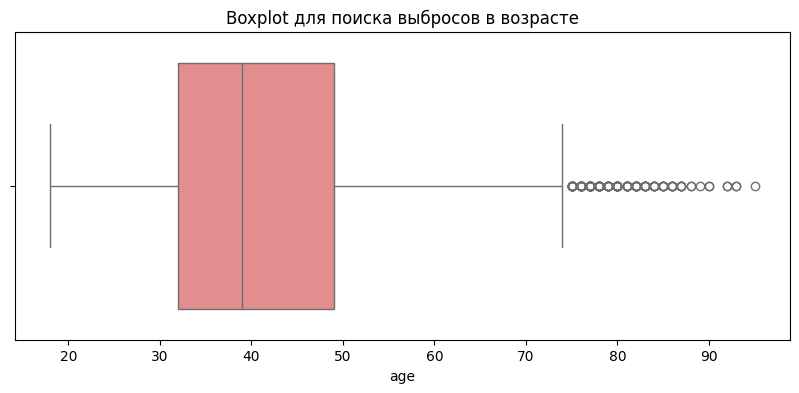

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print(f"Найдено выбросов в 'age': {len(outliers)}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['age'], color='lightcoral')
plt.title('Boxplot для поиска выбросов в возрасте')
plt.show()

# 4. Визуализация данных (EDA)

### 4.1. Распределение ключевого числового признака (Возраст)
Большинство клиентов находятся в диапазоне 30-50 лет. Распределение имеет правостороннюю асимметрию.

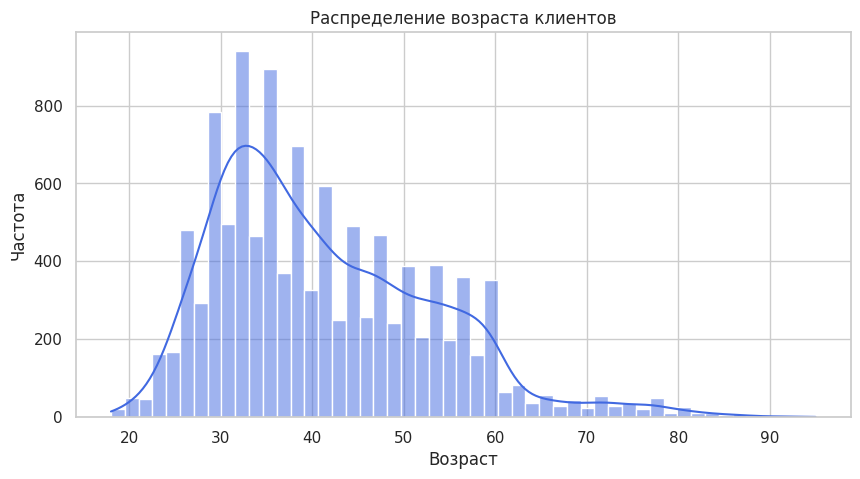

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['age'], kde=True, color='royalblue')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

### 4.2. Распределение категориального признака (Результат кампании)
Классы распределены относительно равномерно, что благоприятно для обучения моделей.

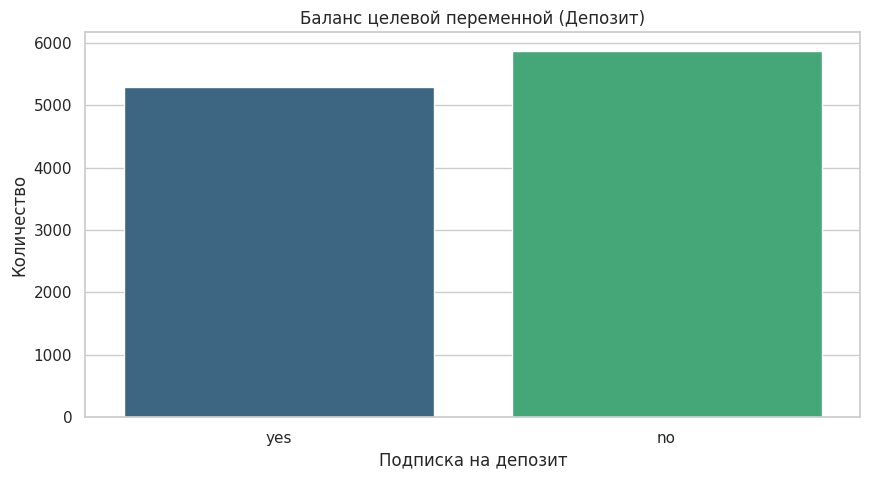

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(x='deposit', data=df, palette='viridis', hue='deposit', legend=False)
plt.title('Баланс целевой переменной (Депозит)')
plt.xlabel('Подписка на депозит')
plt.ylabel('Количество')
plt.show()

### 4.3. Визуализация зависимости (Возраст vs Депозит)
Заметно, что более молодые и более пожилые люди чаще соглашаются на депозит.

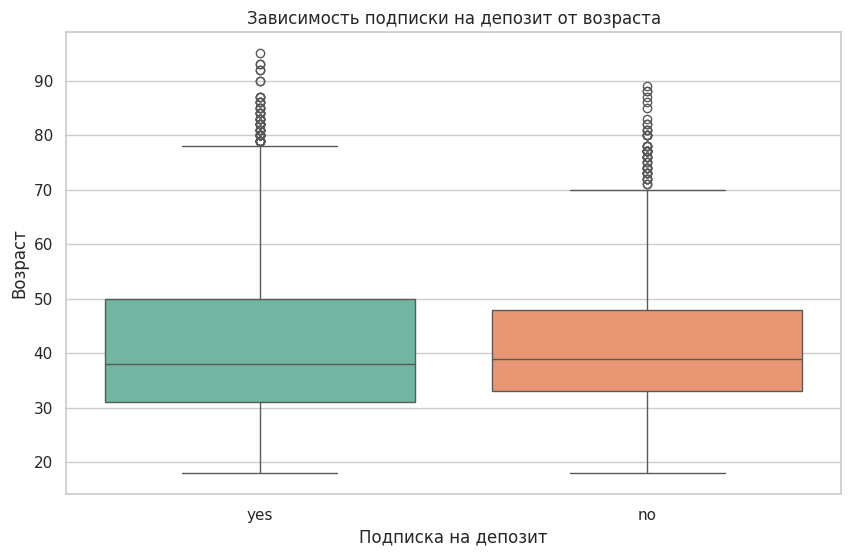

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='deposit', y='age', data=df, palette='Set2', hue='deposit', legend=False)
plt.title('Зависимость подписки на депозит от возраста')
plt.xlabel('Подписка на депозит')
plt.ylabel('Возраст')
plt.show()